In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import os
import torch
from tqdm.auto import tqdm

from JacobianODE.jacobians import (
    load_config,
    initialize_config,
    seed_everything,
    make_trajectories,
    postprocess_data,
)
from JacobianODE.fnn import loss_amplification
from JacobianODE.jacobians.data import embed_signal_torch

In [6]:
# Standard Lorenz config (data=dysts defaults to Lorenz, 32 trials, 12 periods, 100 pts/period)
cfg = load_config(overrides=[
    "data=dysts",
    # "data.postprocessing.obs_noise=0.05",
    "data.postprocessing.obs_noise=0.01",
    f"training.logger.save_dir={os.getcwd()}",
])
cfg = initialize_config(cfg)
seed_everything(cfg.data.flow.random_state + cfg.training.run_number)

eq, sol, dt = make_trajectories(cfg, verbose=True)
values_raw = sol["values"]  # shape (n_trials, n_timepoints, n_dims)
result = postprocess_data(cfg, values_raw)
values = result.values
print(f"Loaded Lorenz: {values.shape}, dt={dt:.4f}")
x = torch.from_numpy(values)[..., [0]]
print(f"Generate x: {x.shape}")

Loaded Lorenz: (32, 1200, 3), dt=0.0150
Generate x: torch.Size([32, 1200, 1])


In [ ]:
import torch

def compute_local_conformal_variance(x_true, x_embed, n_points=2000, n_neighbors=10, eps=1e-8):
    """
    Computes the local conformal variance between a true state space and an embedding space.
    A lower value indicates that the embedding is closer to a local scaled isometry (conformal mapping).
    
    Args:
        x_embed: Tensor or numpy array of the embedded coordinates (e.g., delay embedding or latent space).
        x_true: Tensor or numpy array of the true state coordinates.
        n_points: Number of points to sample/evaluate (defaults to 2000). If None, uses all points.
        n_neighbors: Number of local neighbors to use for the variance calculation.
        eps: Small value for numerical stability in sqrt and log operations.
        
    Returns:
        mean_local_var: A scalar torch.Tensor representing the mean local log-variance.
    """
    # 1. Setup and shape formatting
    x_embed_flat = x_embed.reshape(-1, x_embed.shape[-1])
    x_true_flat = x_true.reshape(-1, x_true.shape[-1])
    
    # Ensure both are PyTorch tensors (and float32 for stable gradient computation if training)
    if not isinstance(x_true_flat, torch.Tensor):
        x_true_flat = torch.from_numpy(x_true_flat).float()
    if not isinstance(x_embed_flat, torch.Tensor):
        x_embed_flat = torch.from_numpy(x_embed_flat).float()

    # Slice the arrays if n_points is specified
    if n_points is not None:
        x_true_flat = x_true_flat[:n_points]
        x_embed_flat = x_embed_flat[:n_points]

    # 2. Compute global distances for the true system to find neighborhoods
    # Note: If using this strictly as a loss function where x_true is unknown, 
    # you would compute these neighbors using the observation/delay space instead.
    dist_true = torch.cdist(x_true_flat, x_true_flat)

    # 3. Find the K nearest neighbors (excluding the point itself, hence 1:)
    _, indices = torch.topk(dist_true, n_neighbors + 1, largest=False)
    indices = indices[:, 1:] # Shape: (n_points, n_neighbors)

    # 4. Extract the neighbor coordinates for both spaces
    x_true_nbrs = x_true_flat[indices]   # Shape: (n_points, n_neighbors, true_dim)
    x_embed_nbrs = x_embed_flat[indices] # Shape: (n_points, n_neighbors, embed_dim)

    # 5. Compute pairwise SQUARED distances within each neighborhood
    # unsqueeze(2) -> (n, K, 1, dim), unsqueeze(1) -> (n, 1, K, dim)
    diff_true_sq = (x_true_nbrs.unsqueeze(2) - x_true_nbrs.unsqueeze(1)).pow(2).sum(dim=-1) 
    diff_embed_sq = (x_embed_nbrs.unsqueeze(2) - x_embed_nbrs.unsqueeze(1)).pow(2).sum(dim=-1)       

    # 6. Extract the lower triangular indices to get unique pairs within the neighborhood
    K = diff_true_sq.shape[1]
    tril_idx = torch.tril_indices(K, K, offset=-1)

    # Extract the pairs without flattening the batch dimension
    # Shape remains (n_points, K*(K-1)/2)
    diff_true_tril_sq = diff_true_sq[:, tril_idx[0], tril_idx[1]]
    diff_embed_tril_sq = diff_embed_sq[:, tril_idx[0], tril_idx[1]]

    # 7. Convert to actual Euclidean distances
    dist_true_tril = torch.sqrt(diff_true_tril_sq + eps)
    dist_embed_tril = torch.sqrt(diff_embed_tril_sq + eps)

    # 8. Compute the Log-Differences (Log-Ratios)
    log_dist_true = torch.log(dist_true_tril + eps)
    log_dist_embed = torch.log(dist_embed_tril + eps)
    log_ratios = log_dist_embed - log_dist_true # Shape: (n_points, K*(K-1)/2)

    # 9. Compute the LOCAL variance (across the pairs strictly WITHIN each neighborhood)
    local_variances = torch.var(log_ratios, dim=1, unbiased=False) # unbiased=False handles small K better

    # 10. Aggregate the local variances
    mean_local_var = torch.mean(local_variances)

    return mean_local_var

In [77]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
amplification_losses = {}
conformal_vars = {}
N_DELAYS_VALS = np.arange(1, 51)
INTERVAL_VALS = np.arange(1, 21)

iterator = tqdm(total=len(N_DELAYS_VALS) * len(INTERVAL_VALS))

x_full = torch.from_numpy(values).to(device)
for n_delays in N_DELAYS_VALS:
    for delay_interval in INTERVAL_VALS:
        x_embedded = embed_signal_torch(x, n_delays, delay_interval).to(device)
        x_data = x_embedded[..., :x.shape[-1]].to(device)

        loss = loss_amplification(x_embedded.to(device), x_data.to(device), max_T=25, n_neighbors=10, normalize=True)
        amplification_losses[(n_delays, delay_interval)] = loss.item()

        x_true = x_full[..., x_full.shape[-2] - x_embedded.shape[-2]:, :]
        conformal_vars[(n_delays, delay_interval)] = compute_local_conformal_variance(x_true, x_embedded)

        iterator.update(1)
iterator.close()

  0%|          | 0/1000 [00:00<?, ?it/s]

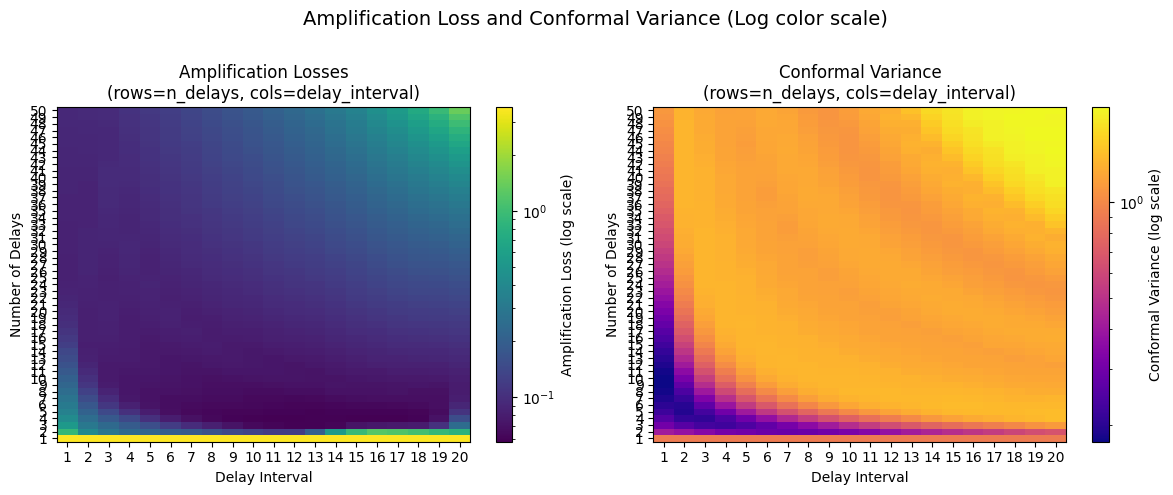

In [78]:
import numpy as np
from matplotlib.colors import LogNorm

# Convert the amplification_losses dict to a 2D array for plotting
n_delays_max = max(N_DELAYS_VALS)
interval_max = max(INTERVAL_VALS)
loss_matrix = np.zeros((n_delays_max, interval_max))
conformal_matrix = np.zeros((n_delays_max, interval_max))

for (n_delays, delay_interval), loss in amplification_losses.items():
    loss_matrix[n_delays-1, delay_interval-1] = float(loss)
for (n_delays, delay_interval), confvar in conformal_vars.items():
    conformal_matrix[n_delays-1, delay_interval-1] = float(confvar)

# To avoid issues with log scale, make sure there are no zeros (replace with a small value if necessary)
loss_matrix_for_log = np.where(
    loss_matrix > 0, 
    loss_matrix, 
    np.nanmin(loss_matrix[np.nonzero(loss_matrix)]) * 0.1
)
# Do similar for conformal variance
conformal_matrix_for_log = np.where(
    conformal_matrix > 0, 
    conformal_matrix, 
    np.nanmin(conformal_matrix[np.nonzero(conformal_matrix)]) * 0.1
)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Amplification Loss
im0 = axes[0].imshow(
    loss_matrix_for_log,
    origin="lower",
    aspect="auto",
    cmap="viridis",
    norm=LogNorm(vmin=np.nanmin(loss_matrix_for_log), vmax=np.nanmax(loss_matrix_for_log))
)
cbar0 = plt.colorbar(im0, ax=axes[0], label='Amplification Loss (log scale)')
axes[0].set_xticks(np.arange(interval_max))
axes[0].set_yticks(np.arange(n_delays_max))
axes[0].set_xticklabels(np.arange(1, interval_max + 1))
axes[0].set_yticklabels(np.arange(1, n_delays_max + 1))
axes[0].set_xlabel("Delay Interval")
axes[0].set_ylabel("Number of Delays")
axes[0].set_title("Amplification Losses\n(rows=n_delays, cols=delay_interval)")

# Conformal Variance
im1 = axes[1].imshow(
    conformal_matrix_for_log,
    origin="lower",
    aspect="auto",
    cmap="plasma",
    norm=LogNorm(vmin=np.nanmin(conformal_matrix_for_log), vmax=np.nanmax(conformal_matrix_for_log))
)
cbar1 = plt.colorbar(im1, ax=axes[1], label='Conformal Variance (log scale)')
axes[1].set_xticks(np.arange(interval_max))
axes[1].set_yticks(np.arange(n_delays_max))
axes[1].set_xticklabels(np.arange(1, interval_max + 1))
axes[1].set_yticklabels(np.arange(1, n_delays_max + 1))
axes[1].set_xlabel("Delay Interval")
axes[1].set_ylabel("Number of Delays")
axes[1].set_title("Conformal Variance\n(rows=n_delays, cols=delay_interval)")

fig.suptitle("Amplification Loss and Conformal Variance (Log color scale)", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
conformal_flat.min()            u

np.float64(0.17785186290077756)

In [80]:
from scipy.stats import pearsonr

# Compute correlation between the conformal variance and amplification loss matrices (flatten non-nan)
valid = (~np.isnan(loss_matrix_for_log)) & (~np.isnan(conformal_matrix_for_log))
loss_flat = loss_matrix_for_log[valid].flatten()
conformal_flat = conformal_matrix_for_log[valid].flatten()

corr, pval = pearsonr(loss_flat, conformal_flat)
print(f"Correlation between amplification loss and conformal variance: r={corr:.3f} (p={pval:.2g})")

Correlation between amplification loss and conformal variance: r=-0.044 (p=0.16)


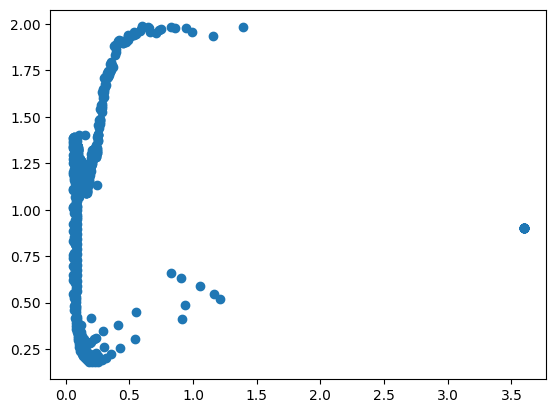

In [81]:
plt.scatter(loss_flat, conformal_flat)

In [10]:
# Find the (n_delays, delay_interval) that gives the minimum amplification loss
best_params = min(amplification_losses, key=amplification_losses.get)
best_n_delays, best_delay_interval = best_params
best_loss = amplification_losses[best_params]

print(f"Best amplification loss: {best_loss:.5g} at n_delays={best_n_delays}, delay_interval={best_delay_interval}")

# Generate the embedding with these optimal parameters
best_x_embedded = embed_signal_torch(x, best_n_delays, best_delay_interval)

Best amplification loss: 0.057835 at n_delays=4, delay_interval=11


In [11]:
# Mean center embedded data
x_emb_flat = best_x_embedded.reshape(-1, best_x_embedded.shape[-1])
x_emb_flat_centered = x_emb_flat - torch.mean(x_emb_flat, dim=0, keepdim=True)

# Compute covariance matrix (torch, rowvar=False)
cov = torch.cov(x_emb_flat_centered.T)

# Eigendecomposition, torch returns eigvals in ascending order, so flip for descending
eigvals, eigvecs = torch.linalg.eigh(cov)
eigvals = eigvals.flip(dims=(0,))
eigvecs = eigvecs.flip(dims=(1,))

# Participation ratio (torch)
pr = (eigvals.sum())**2 / (eigvals**2).sum()
print(f"Participation Ratio: {pr.item():.3f}")

# Project mean-centered data onto principal components, most variance first
x_emb_pca = x_emb_flat_centered @ eigvecs

Participation Ratio: 1.366


In [12]:
# Mean center embedded data for values_raw
values_emb_flat = values_raw.reshape(-1, values_raw.shape[-1])
values_emb_flat = torch.from_numpy(values_emb_flat)
values_emb_flat_centered = values_emb_flat - torch.mean(values_emb_flat, dim=0, keepdim=True)

# Compute covariance matrix (torch, rowvar=False)
values_cov = torch.cov(values_emb_flat_centered.T)

# Eigendecomposition, torch returns eigvals in ascending order, so flip for descending
values_eigvals, values_eigvecs = torch.linalg.eigh(values_cov)
values_eigvals = values_eigvals.flip(dims=(0,))
values_eigvecs = values_eigvecs.flip(dims=(1,))

# Participation ratio (torch)
values_pr = (values_eigvals.sum())**2 / (values_eigvals**2).sum()
print(f"Participation Ratio (values_raw): {values_pr.item():.3f}")

# Project mean-centered data onto principal components, most variance first
values_emb_pca = values_emb_flat_centered @ values_eigvecs

Participation Ratio (values_raw): 1.668


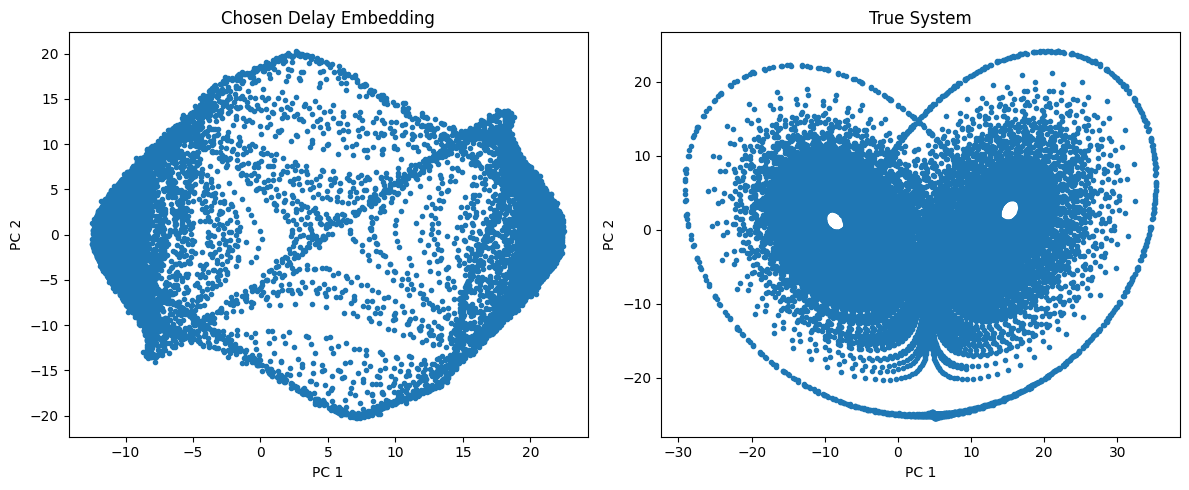

In [13]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

axs[0].plot(x_emb_pca[:, 0], x_emb_pca[:, 1], '.')
axs[0].set_title('Chosen Delay Embedding')
axs[0].set_xlabel('PC 1')
axs[0].set_ylabel('PC 2')

axs[1].plot(values_emb_pca[:, 0], values_emb_pca[:, 1], '.')
axs[1].set_title('True System')
axs[1].set_xlabel('PC 1')
axs[1].set_ylabel('PC 2')

plt.tight_layout()
plt.show()

In [14]:
x_de, x_true = best_x_embedded, values[..., values.shape[-2] - best_x_embedded.shape[-2]:, :]